In [5]:
# Cell 1: Install and import dependencies (run installs only if needed)

# If you don't have these yet, uncomment and run:
# !pip install pandas scipy statsmodels seaborn matplotlib

import pandas as pd
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns


In [6]:
# Cell 2: Load the CSV from GitHub into a pandas DataFrame

CSV_URL = "https://raw.githubusercontent.com/nailson/ifood-data-business-analyst-test/master/ifood_df.csv"

ifood_df = pd.read_csv(CSV_URL)

ifood_df.head()


,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
0,58138.0,0,0,58,635,88,546,172,88,88,...,0,0,0,0,1,0,0,1529,1441,0
1,46344.0,1,1,38,11,1,6,2,1,6,...,0,0,0,0,1,0,0,21,15,0
2,71613.0,0,0,26,426,49,127,111,21,42,...,1,0,0,0,1,0,0,734,692,0
3,26646.0,1,0,26,11,4,20,10,3,5,...,1,0,0,0,1,0,0,48,43,0
4,58293.0,1,0,94,173,43,118,46,27,15,...,0,0,0,0,0,0,1,407,392,0


In [18]:
# Cell 3: Basic inspection and choice of variables for ANOVA

print("Shape:", ifood_df.shape)
print("\nColumns:\n", ifood_df.columns.tolist())

# IMPORTANT: Check the printed list, then set these two names to match exactly
# what you see. For the official iFood dataset, they are usually 'MntWines'
# and 'Marital_Status'. If yours differ (e.g. 'Marital Status'), change below.

dv_col = "MntFruits"         # dependent variable (numeric)
factor_col = "Kidhome"  # categorical factor

print(f"\nUnique values for factor column '{factor_col}':")
print(ifood_df[factor_col].value_counts())



Shape: (2205, 39)

Columns:
 ['Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response', 'Age', 'Customer_Days', 'marital_Divorced', 'marital_Married', 'marital_Single', 'marital_Together', 'marital_Widow', 'education_2n Cycle', 'education_Basic', 'education_Graduation', 'education_Master', 'education_PhD', 'MntTotal', 'MntRegularProds', 'AcceptedCmpOverall']

Unique values for factor column 'Kidhome':
Kidhome
0    1276
1     883
2      46
Name: count, dtype: int64


In [19]:
# Cell 4: One-way ANOVA with scipy.stats.f_oneway

anova_df = ifood_df[[dv_col, factor_col]].dropna().copy()

groups = []
labels = []

for level, group in anova_df.groupby(factor_col):
    values = group[dv_col].values
    if len(values) > 0:
        groups.append(values)
        labels.append(level)

F_stat, p_value = stats.f_oneway(*groups)

print(f"One-way ANOVA on {dv_col} by {factor_col}")
print("Groups:", labels)
print(f"F-statistic: {F_stat:.4f}")
print(f"p-value: {p_value:.4e}")

if p_value < 0.05:
    print("\nResult: Reject H0 at alpha = 0.05.\n" \
          f"There is evidence that mean {dv_col} differs by {factor_col}.")
else:
    print("\nResult: Fail to reject H0 at alpha = 0.05.\n" \
          f"We do not have evidence that mean {dv_col} differs by {factor_col}.")


One-way ANOVA on MntFruits by Kidhome
Groups: [0, 1, 2]
F-statistic: 192.3559
p-value: 1.0145e-77

Result: Reject H0 at alpha = 0.05.
There is evidence that mean MntFruits differs by Kidhome.


In [20]:
# Cell 5: ANOVA via statsmodels

model = smf.ols(f"{dv_col} ~ C({factor_col})", data=anova_df).fit()

anova_table = sm.stats.anova_lm(model, typ=2)

print("ANOVA table using OLS model:")
print(anova_table)


ANOVA table using OLS model:
                  sum_sq      df          F        PR(>F)
C(Kidhome)  5.188318e+05     2.0  192.35592  1.014517e-77
Residual    2.969671e+06  2202.0        NaN           NaN


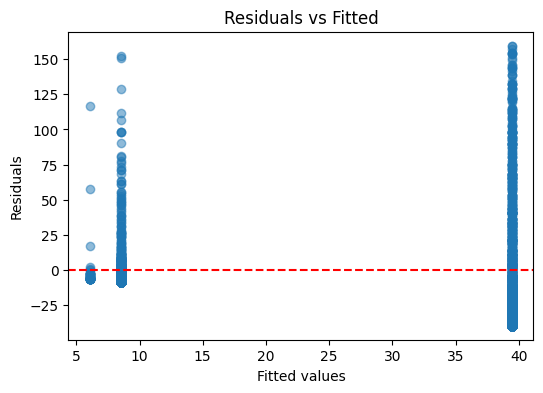

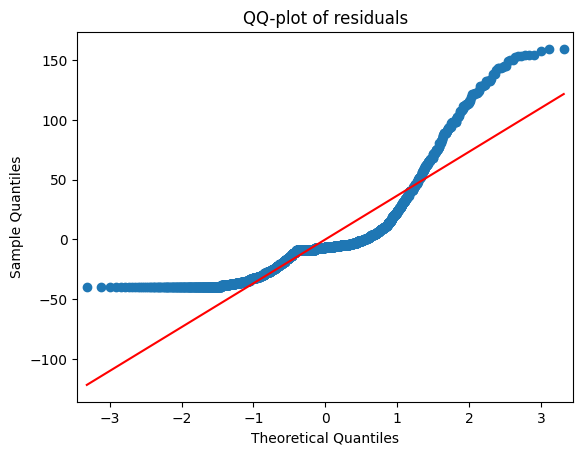

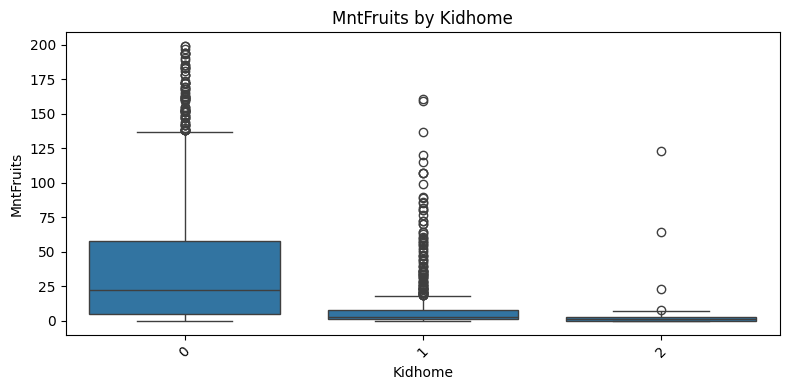

In [21]:
# Cell 6: Diagnostics and visualization (optional)

# Residuals vs fitted
fitted = model.fittedvalues
residuals = model.resid

plt.figure(figsize=(6, 4))
plt.scatter(fitted, residuals, alpha=0.5)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

# QQ-plot of residuals
sm.qqplot(residuals, line="s")
plt.title("QQ-plot of residuals")
plt.show()

# Boxplot of DV by factor
plt.figure(figsize=(8, 4))
sns.boxplot(data=anova_df, x=factor_col, y=dv_col)
plt.xticks(rotation=45)
plt.title(f"{dv_col} by {factor_col}")
plt.tight_layout()
plt.show()


In [22]:
print(ifood_df.columns.tolist())


['Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response', 'Age', 'Customer_Days', 'marital_Divorced', 'marital_Married', 'marital_Single', 'marital_Together', 'marital_Widow', 'education_2n Cycle', 'education_Basic', 'education_Graduation', 'education_Master', 'education_PhD', 'MntTotal', 'MntRegularProds', 'AcceptedCmpOverall']
